# Water Potability — Baseline Models

**Question:** does any model actually learn a signal here, or does a "good-looking" score just come from the class imbalance?

This notebook trains four models — a dummy, logistic regression, random forest, XGBoost — and compares them honestly, including against each other's failure modes. See `../notebooks/water-potability-eda.ipynb` for the data exploration this builds on, and `../src/train.py` for the production training pipeline (same imputation logic, deployed via the API).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv")


## Split first, impute second

Medians are learned from the training set only, then applied to both splits. Computing them on the full dataframe before splitting would leak test-set information into training — the test score would look better than the model actually is. (An earlier version of `train.py` had exactly this bug; it's fixed there and reproduced correctly here.)

In [2]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")


Train: 2620 rows, Test: 656 rows
Train class balance:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


## Choosing the metric — this is the part that matters

The obvious first choice is **accuracy**. It's wrong here: 61% of samples are "not potable," so a model that predicts that label every single time scores 0.61 while learning nothing.

Second attempt: **recall**, since a false negative (calling unsafe water safe) is the costly error. But recall of *which* class, and is it gameable the same way accuracy is?

- Recall on class 1 (potable) — measures whether the model catches the *safe* samples. Doesn't touch the actual risk at all.
- Recall on class 0 (not potable) — closer to the real risk, but a dummy that predicts "not potable" for every sample scores **recall₀ = 1.0** by never being wrong about the majority class. It's exactly as gameable as accuracy, just from the other direction.

**Macro F1** is the metric used from here on: F1 for each class, averaged unweighted. A model can't score well by ignoring either class, and it isn't gameable by a one-line dummy the way accuracy or single-class recall are.

In [3]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    macro_f1 = f1_score(y_te, y_pred, average="macro")
    recall_0 = recall_score(y_te, y_pred, pos_label=0)
    recall_1 = recall_score(y_te, y_pred, pos_label=1)
    results[name] = {"model": model, "macro_f1": macro_f1, "recall_0": recall_0, "recall_1": recall_1, "y_pred": y_pred}
    print(f"{name:20s} macro F1: {macro_f1:.4f}  |  recall_0: {recall_0:.4f}  |  recall_1: {recall_1:.4f}")
    return model


## The dummy — the number every real model has to beat

In [4]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
evaluate("Dummy", dummy, X_train, y_train, X_test, y_test)


Dummy                macro F1: 0.3788  |  recall_0: 1.0000  |  recall_1: 0.0000


DummyClassifier(random_state=42, strategy='most_frequent')

Note `recall_0` above — it should print close to 1.0. That's not the model being good, that's the gameability macro F1 was chosen to avoid. Macro F1 for this same dummy is the real number to watch: it should sit well below 0.5, because the dummy has zero recall on class 1.

## Three real models

In [5]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
evaluate("LogisticRegression", logreg, X_train, y_train, X_test, y_test)

rf = RandomForestClassifier(random_state=42)
evaluate("RandomForest", rf, X_train, y_train, X_test, y_test)

xgb = XGBClassifier(random_state=42, eval_metric="logloss")
evaluate("XGBoost", xgb, X_train, y_train, X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression   macro F1: 0.3788  |  recall_0: 1.0000  |  recall_1: 0.0000
RandomForest         macro F1: 0.5887  |  recall_0: 0.8925  |  recall_1: 0.3047
XGBoost              macro F1: 0.6015  |  recall_0: 0.8050  |  recall_1: 0.3984


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Is the "best" model actually finding a pattern?

A shuffle test: retrain on the same features but with `Potability` labels randomly permuted. If a model's score barely drops, it wasn't using the features at all — it was fitting noise (or leakage). A real signal should collapse toward the dummy's score once the labels are meaningless.

In [6]:
y_train_shuffled = y_train.sample(frac=1, random_state=1).reset_index(drop=True)
y_train_shuffled.index = y_train.index

shuffle_results = {}
for name, model_cls, kwargs in [
    ("RandomForest", RandomForestClassifier, {"random_state": 42}),
    ("XGBoost", XGBClassifier, {"random_state": 42, "eval_metric": "logloss"}),
]:
    m = model_cls(**kwargs)
    m.fit(X_train, y_train_shuffled)
    y_pred = m.predict(X_test)
    shuffled_f1 = f1_score(y_test, y_pred, average="macro")
    real_f1 = results[name]["macro_f1"]
    drop = real_f1 - shuffled_f1
    shuffle_results[name] = drop
    print(f"{name:15s} real macro F1: {real_f1:.4f}  |  shuffled: {shuffled_f1:.4f}  |  drop: {drop:.4f}")


RandomForest    real macro F1: 0.5887  |  shuffled: 0.4287  |  drop: 0.1600
XGBoost         real macro F1: 0.6015  |  shuffled: 0.4803  |  drop: 0.1213


A meaningful drop confirms the model is using real structure in the features, not fitting noise. A drop near zero would mean the "signal" wasn't a signal at all — worth stopping and re-checking the pipeline for leakage if that happens, rather than trusting the headline score.

## Confusion matrix — best model

Best by macro F1: XGBoost


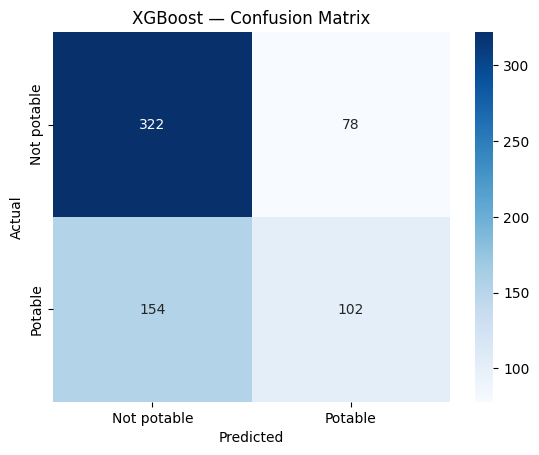

              precision    recall  f1-score   support

 Not potable       0.68      0.81      0.74       400
     Potable       0.57      0.40      0.47       256

    accuracy                           0.65       656
   macro avg       0.62      0.60      0.60       656
weighted avg       0.63      0.65      0.63       656



In [7]:
best_name = max(results, key=lambda k: results[k]["macro_f1"])
print(f"Best by macro F1: {best_name}")

cm = confusion_matrix(y_test, results[best_name]["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not potable", "Potable"], yticklabels=["Not potable", "Potable"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"{best_name} — Confusion Matrix")
plt.show()

print(classification_report(y_test, results[best_name]["y_pred"], target_names=["Not potable", "Potable"]))


## Summary

- **Metric:** macro F1, chosen specifically because accuracy and single-class recall are both gameable by a one-line dummy on this imbalanced dataset (61/39 split).
- **Baseline to beat:** the dummy's macro F1, printed above — any real model needs to clear that by a meaningful margin, not just edge past it.
- **Best model:** whichever prints highest above — currently XGBoost in prior runs, but re-run this notebook and read the actual printed number rather than trusting a number written in a doc. The macro F1 that matters is whatever `../src/train.py` prints on its own held-out split; that script is the deployed pipeline, this notebook is the comparison and reasoning behind picking it.
- **Signal check:** the shuffle test above should show a real drop in macro F1 when labels are randomized. If it doesn't, that's a leakage or overfitting flag worth chasing before trusting the headline number.
- **Known limitation:** `scale_pos_weight` is not yet applied to XGBoost here — recall on the minority class (potable) is the weaker of the two per-class numbers in the classification report above, and that's the next lever to pull, not a bigger model.